In [1]:
import pandas as pd

In [2]:
df = pd.read_excel("bankruptcy-prevention.xlsx")

In [3]:
df = df.iloc[:, 0].str.split(";", expand=True)

df.columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk",
    "class"
]

In [4]:
df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1,0,0,0,0.5,bankruptcy
1,0,1,0,0,0,1,bankruptcy
2,1,0,0,0,0,1,bankruptcy
3,0.5,0,0,0.5,0,1,bankruptcy
4,1,1,0,0,0,1,bankruptcy


In [5]:
df.shape

(250, 7)

#### Dataset Information

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 7 columns):
 #   Column                 Non-Null Count  Dtype
---  ------                 --------------  -----
 0   industrial_risk        250 non-null    str  
 1   management_risk        250 non-null    str  
 2   financial_flexibility  250 non-null    str  
 3   credibility            250 non-null    str  
 4   competitiveness        250 non-null    str  
 5   operating_risk         250 non-null    str  
 6   class                  250 non-null    str  
dtypes: str(7)
memory usage: 13.8 KB


#### Statistical Summary

In [7]:
df.describe().T

,count,unique,top,freq
industrial_risk,250,3,1,89
management_risk,250,3,1,119
financial_flexibility,250,3,0,119
credibility,250,3,0,94
competitiveness,250,3,0,103
operating_risk,250,3,1,114
class,250,2,non-bankruptcy,143


#### Missing Values Analysis

In [8]:
df.isnull().sum()

industrial_risk          0
management_risk          0
financial_flexibility    0
credibility              0
competitiveness          0
operating_risk           0
class                    0
dtype: int64

#### Duplicate Values Analysis

In [9]:
df.duplicated().sum()

np.int64(147)

###### Although the dataset contains 147 duplicate rows, I did not remove them because the dataset has no unique company identifier. Since all features have limited categorical values (0, 0.5, and 1), multiple companies can legitimately have identical feature combinations. Removing these records could result in loss of valid observations.

#### Data Type Conversion

In [10]:
feature_columns = [
    "industrial_risk",
    "management_risk",
    "financial_flexibility",
    "credibility",
    "competitiveness",
    "operating_risk"
]

df[feature_columns] = df[feature_columns].apply(pd.to_numeric)

#### Target variable analysis 

In [11]:
df['class'].value_counts()

class
non-bankruptcy    143
bankruptcy        107
Name: count, dtype: int64

### Univariate Analysis

#### Count Plot of Feature Variables

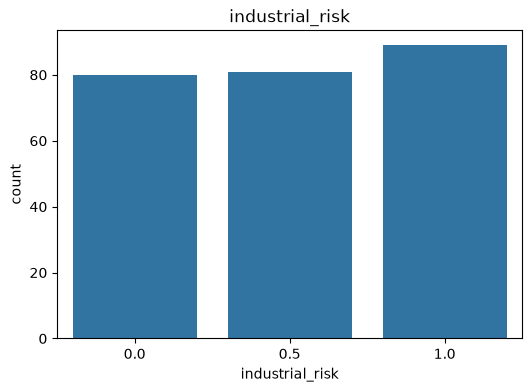

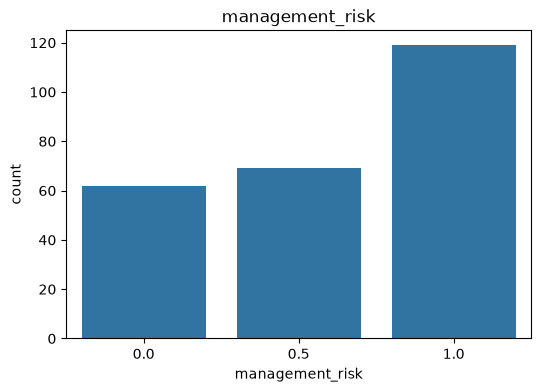

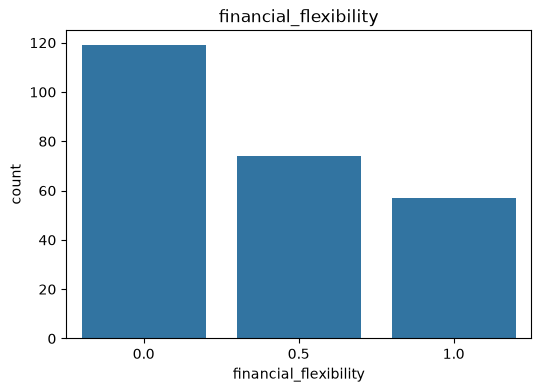

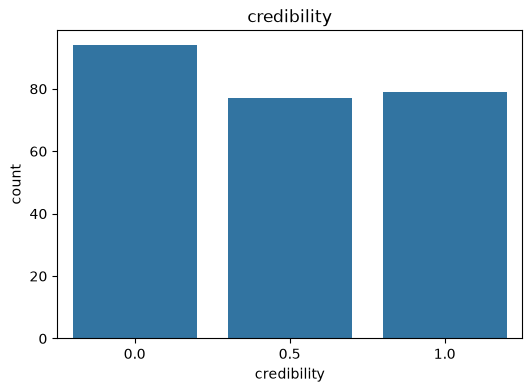

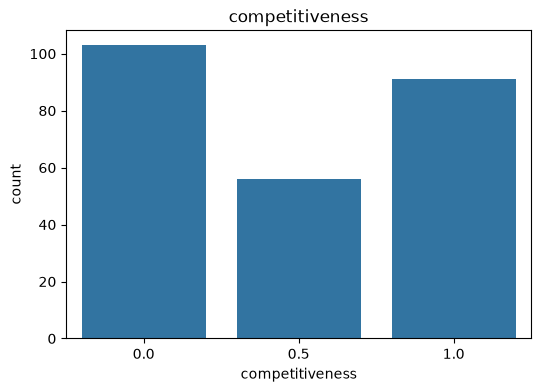

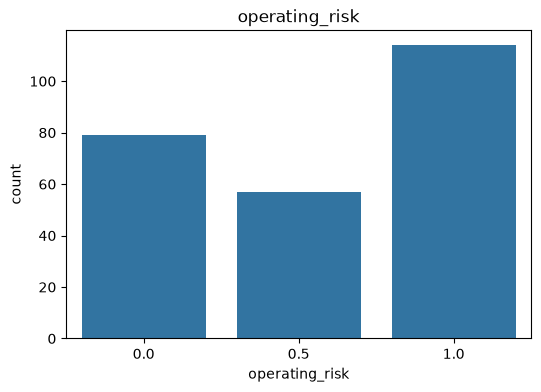

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

for col in df.select_dtypes(include=['int64', 'float64']):
    plt.figure(figsize=(6,4))
    sns.countplot(x=df[col])
    plt.title(col)
    plt.show()

### Bivariate Analysis

#### Feature Variables vs Target Variable

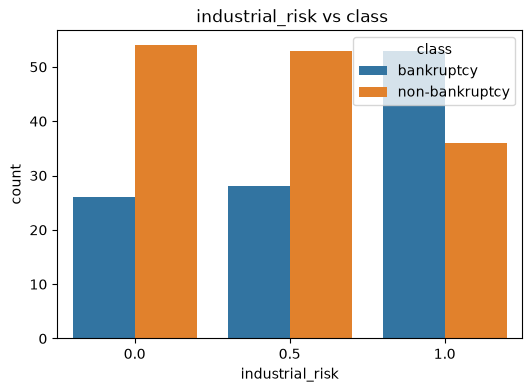

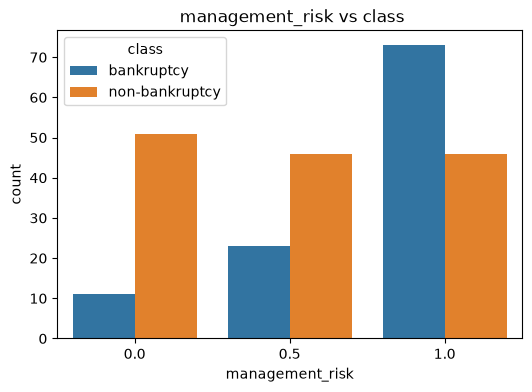

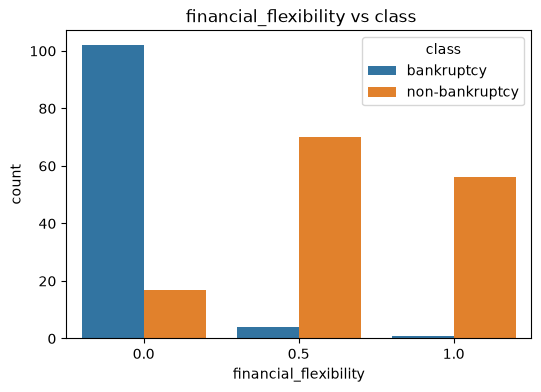

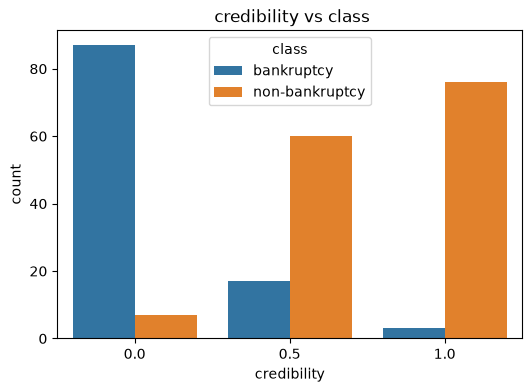

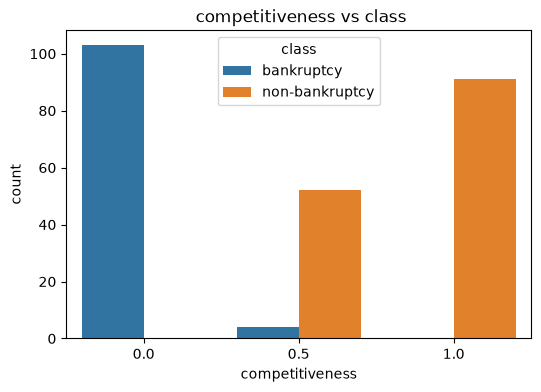

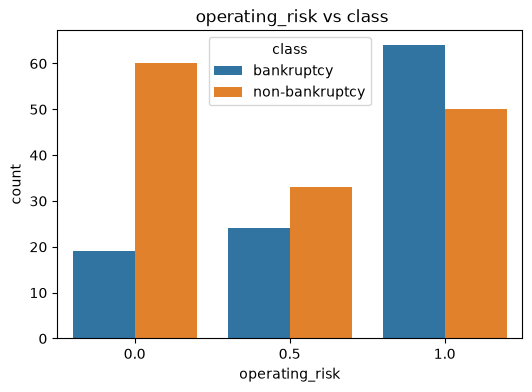

In [13]:
for col in df.select_dtypes(include=['int64', 'float64']):
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue='class')
    plt.title(f" {col} vs class")
    plt.show()

#### Outlier Analysis

###### Outlier analysis was not performed because all input features are ordinal risk categories with predefined values (0, 0.5, 1), where extreme values represent valid risk levels rather than anomalies.

#### Feature and Target Separation

In [14]:
X = df.drop('class', axis=1)

y = df['class']

#### Target Variable Encoding

In [15]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y = le.fit_transform(y)

#### Train-Test Split

In [16]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split (
    X, y, test_size=0.20, random_state=42
)

#### Feature Scaling

In [17]:
from sklearn.preprocessing import StandardScaler

cols = ['industrial_risk', 'management_risk', 'financial_flexibility',
       'credibility', 'competitiveness', 'operating_risk']

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols] = scaler.fit_transform(X_train[cols])
X_test_scaled[cols] = scaler.transform(X_test[cols])

## Logistic Regression

#### Logistic Regression Model Training

In [18]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression()
lr_model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default sol

#### Logistic Regression Prediction

In [19]:
y_pred_lr = lr_model.predict(X_test_scaled)

#### Logistic Regression Model Evaluation

Accuracy Score: 1.0


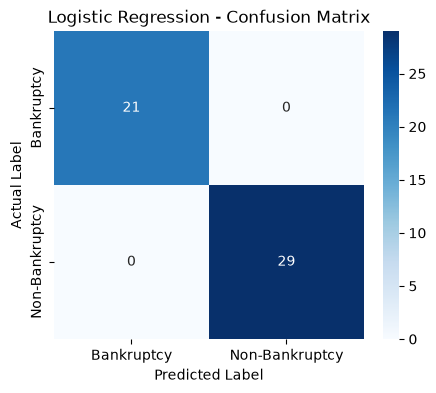


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [20]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lr = accuracy_score(y_test, y_pred_lr)
cm_lr = confusion_matrix(y_test, y_pred_lr)
cr_lr = classification_report(y_test, y_pred_lr)

# Accuracy
print("Accuracy Score:", as_lr)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm_lr,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
    yticklabels=['Bankruptcy', 'Non-Bankruptcy']
)

plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lr)

#### Logistic Regression ROC-AUC Curve

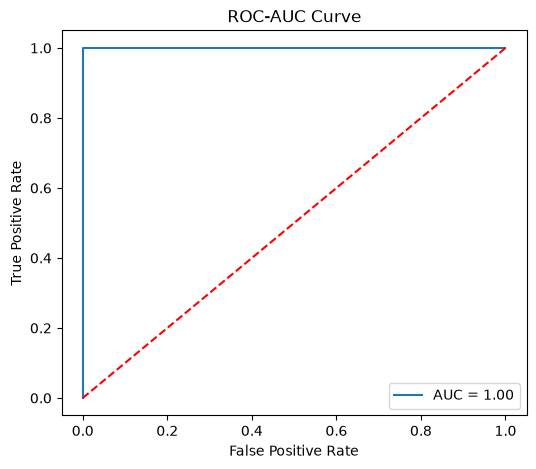

ROC-AUC Score: 0.9999999999999999


In [21]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive class
y_prob_lr = lr_model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lr)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_lr)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## K-Nearest Neighbors (KNN)

#### K-Nearest Neighbors (KNN) Model Training

In [22]:
from sklearn.neighbors import KNeighborsClassifier

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


#### KNN Model Prediction

In [23]:
y_pred_knn = knn_model.predict(X_test_scaled)

#### KNN Model Evaluation

Accuracy Score: 0.98


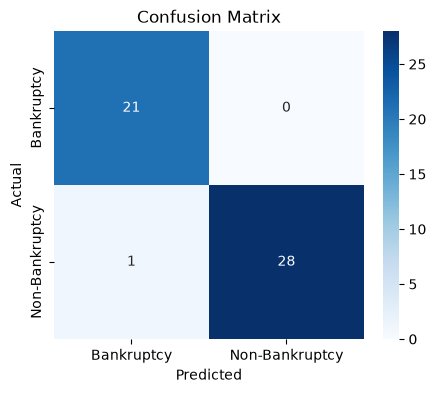


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [24]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_knn = accuracy_score(y_test, y_pred_knn)
cm_knn = confusion_matrix(y_test, y_pred_knn)
cr_knn = classification_report(y_test, y_pred_knn)

# Accuracy Score
print("Accuracy Score:", as_knn)

# Confusion Matrix
plt.figure(figsize=(5,4))

sns.heatmap(cm_knn,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion Matrix
print("\nClassification Report:\n", cr_knn)

#### KNN ROC-AUC Evaluation

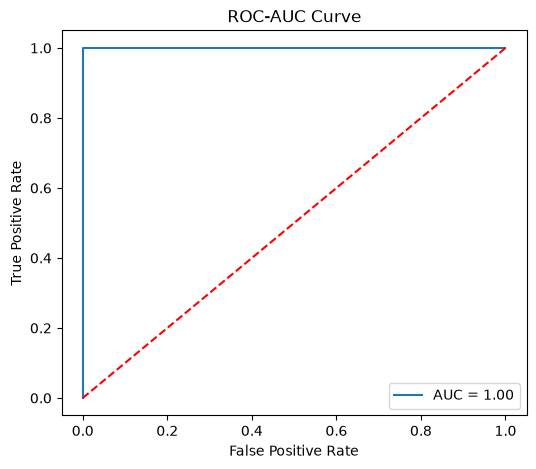

ROC-AUC Score: 1.0


In [25]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive calass
y_prob_knn = knn_model.predict_proba(X_test_scaled)[:,1]

# roc Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_knn)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_knn)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.2f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## Support Vector Machine (SVM)

#### Support Vector Machine (SVM) Model Training

In [26]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)

C:\Users\Akhlaque Alam\ml_new\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",True
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo random number generation for shuffling the data forprobability estimates. Ignored when `probability` is False.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None


#### SVM Model Prediction

In [27]:
y_pred_svm = svm_model.predict(X_test_scaled)

#### SVM Model Evaluation

Accuracy Score: 1.0


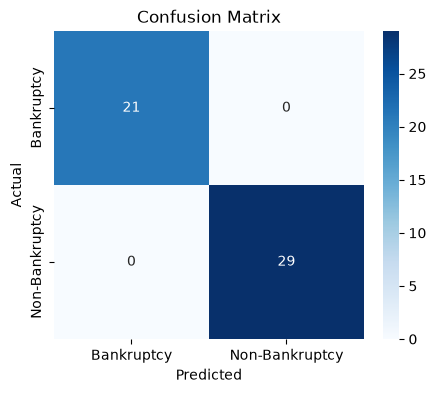


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [28]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_svm = accuracy_score(y_test, y_pred_svm)
cm_svm = confusion_matrix(y_test, y_pred_svm)
cr_svm = classification_report(y_test, y_pred_svm)

# Accuracy
print("Accuracy Score:", as_svm)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_svm)

#### SVM ROC-AUC Evaluation

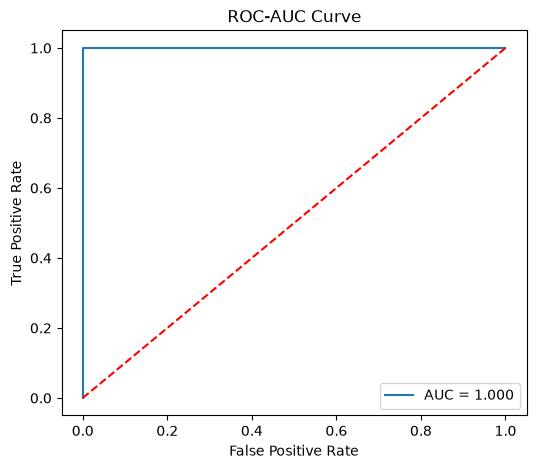

ROC-AUC Score: 1.0


In [29]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of positive Class
y_prob_svm = svm_model.predict_proba(X_test_scaled)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_svm)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## Decision Tree

####  Decision Tree Model Training

In [30]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

####  Decision Tree Model Prediction

In [31]:
y_pred_dt = dt_model.predict(X_test)

#### Decision Tree Model Evaluation

Accuracy Score: 0.98


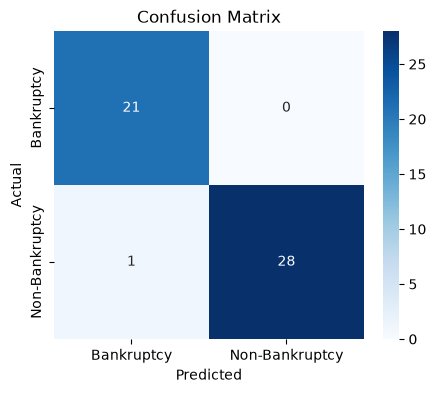


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_dt = accuracy_score(y_test, y_pred_dt)
cm_dt = confusion_matrix(y_test, y_pred_dt)
cr_dt = classification_report(y_test, y_pred_dt)

# Accuracy
print("Accuracy Score:", as_dt)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_dt)

#### Decision Tree ROC-AUC Evaluation

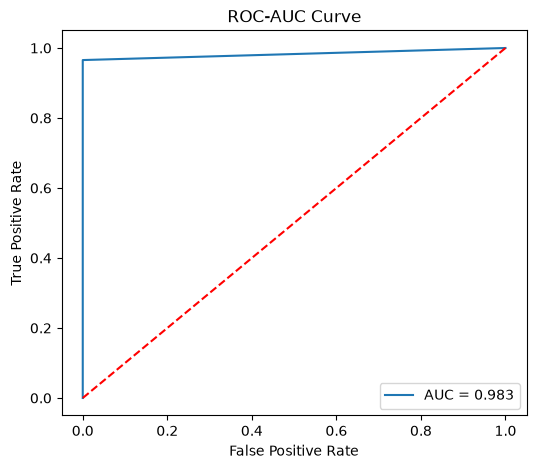

ROC-AUC Score: 0.9827586206896552


In [33]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_dt = dt_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_dt)

# Print
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## Random Forest

#### Random Forest Model Training

In [36]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

#### Random Forest Model Prediction

In [38]:
y_pred_rf = rf_model.predict(X_test)

#### Random Forest Model Evaluation

Accuracy Score: 1.0


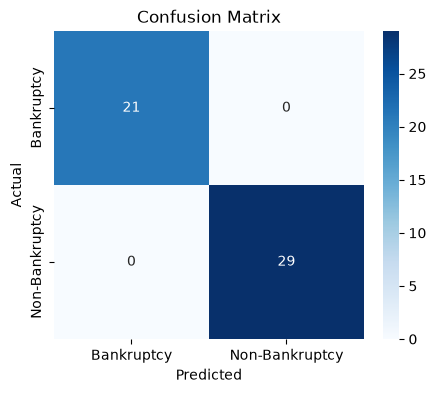


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [42]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_rf = accuracy_score(y_test, y_pred_rf)
cm_rf = confusion_matrix(y_test, y_pred_rf)
cr_rf = classification_report(y_test, y_pred_rf)

# Accuracy
print("Accuracy Score:", as_rf)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_rf)

#### Random Forest ROC-AUC Evaluation

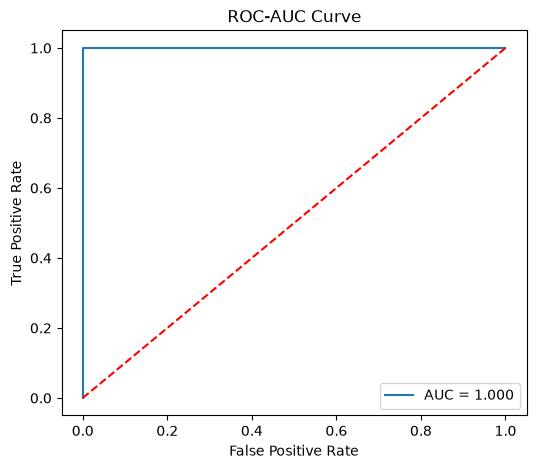

ROC-AUC Score: 1.0


In [46]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probanility of Positive Class
y_prob_rf = rf_model.predict_proba(X_test)[:,1]

# ROC-Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_rf)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc='lower right')
plt.show()

print("ROC-AUC Score:", auc_score)

## Gradient Boosting

#### Gradient Boosting Model Training

In [50]:
from sklearn.ensemble import GradientBoostingClassifier

gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to each Tree estimator at eachboosting iteration.In addition, it controls the random permutation of the features ateach split (see Notes for more details).It also controls the random splitting of the training data to obtain avalidation set if `n_iter_no_change` is not None.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",42
,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'This parameter has no effect... versionadded:: 0.18.. deprecated:: 1.9 `criterion` is deprecated and will be removed in 1.11.",'deprecated'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (im

#### Gradient Boosting Model Prediction

In [52]:
y_pred_gb = gb_model.predict(X_test)

#### Gradient Boosting Model Evaluation

Accuracy Score: 0.98


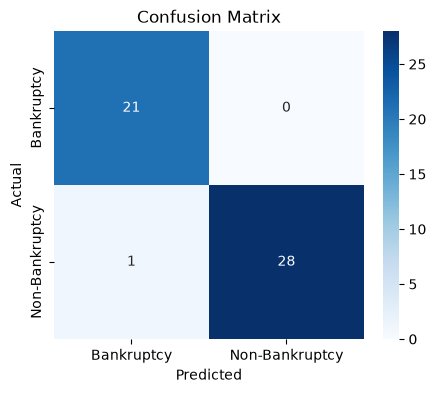


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [55]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_gb = accuracy_score(y_test, y_pred_gb)
cm_gb = confusion_matrix(y_test, y_pred_gb)
cr_gb = classification_report(y_test, y_pred_gb)

# Accuracy
print("Accuracy Score:", as_gb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_gb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_gb)

#### Gradient Boosting ROC-AUC Evaluation

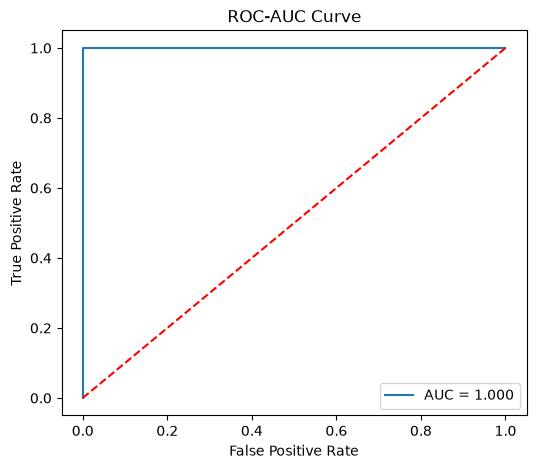

ROC-AUC Score: 1.0


In [59]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_gb = gb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_gb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_gb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## XGBoost Classifier

#### XGBoost Model Training

In [63]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(random_state=42)
xgb_model.fit(X_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


####  XGBoost Model Prediction

In [65]:
y_pred_xgb = xgb_model.predict(X_test)

#### XGBoost Model Evaluation

Accuracy Score: 0.98


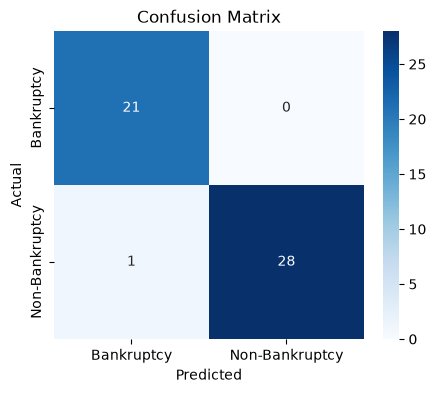


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [67]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_xgb = accuracy_score(y_test, y_pred_xgb)
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
cr_xgb = classification_report(y_test, y_pred_xgb)

# Accuracy
print("Accuracy Score:", as_xgb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_xgb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_xgb)

#### XGBoost ROC-AUC Evaluation

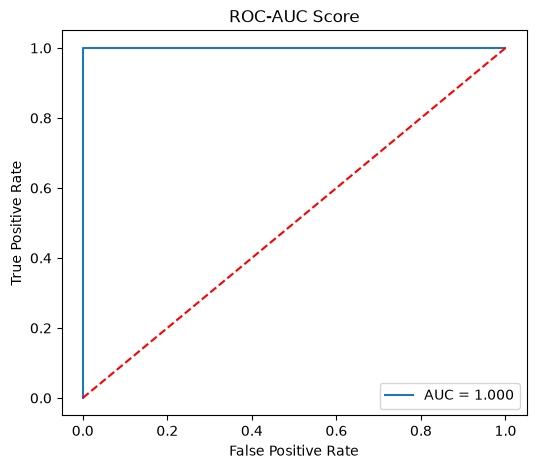

ROC-AUC Score: 1.0


In [70]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_xgb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_xgb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Score")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## LightGBM Classifier

#### LightGBM Model Training

In [75]:
from lightgbm import LGBMClassifier

lgbm_model = LGBMClassifier(verbose=-1,
                            random_state=42
                           )
lgbm_model.fit(X_train, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


#### LightGBM Model Prediction

In [74]:
y_pred_lgbm = lgbm_model.predict(X_test)

#### LightGBM Model Prediction

Accuracy Score: 0.98


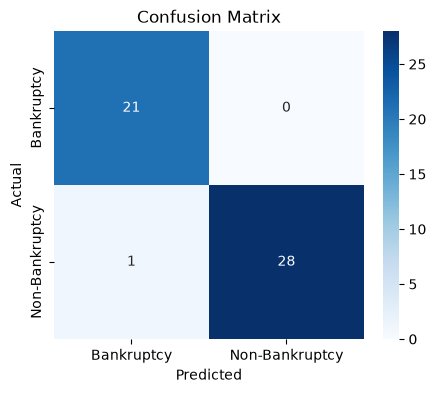


Classification Report:
               precision    recall  f1-score   support

           0       0.95      1.00      0.98        21
           1       1.00      0.97      0.98        29

    accuracy                           0.98        50
   macro avg       0.98      0.98      0.98        50
weighted avg       0.98      0.98      0.98        50



In [78]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_lgbm = accuracy_score(y_test, y_pred_lgbm)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)
cr_lgbm = classification_report(y_test, y_pred_lgbm)

# Accuracy
print("Accuracy Score:", as_lgbm)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_lgbm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_lgbm)

#### LightGBM ROC-AUC Evaluation

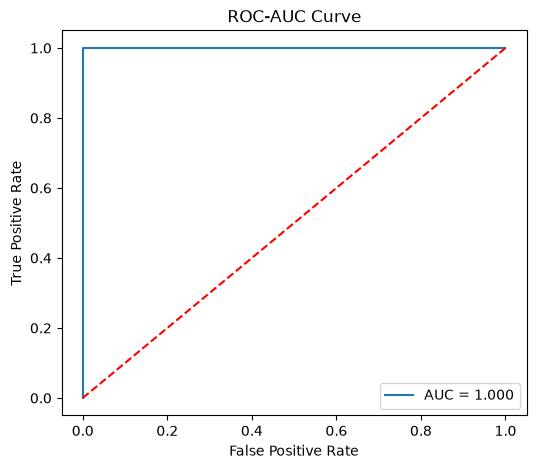

ROC-AUC Score: 1.0


In [79]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_lgbm = lgbm_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_lgbm)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_lgbm)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

## CatBoost Classifier

#### CatBoost Model Training

In [83]:
from catboost import CatBoostClassifier

cb_model = CatBoostClassifier(verbose=0,
                              random_state=42
                             )
cb_model.fit(X_train, y_train)

CatBoostClassifier(random_state=42, verbose=0)

#### CatBoost Model Prediction

In [84]:
y_pred_cb = cb_model.predict(X_test)

#### #### CatBoost Model Evaluation

Accuracy Score: 1.0


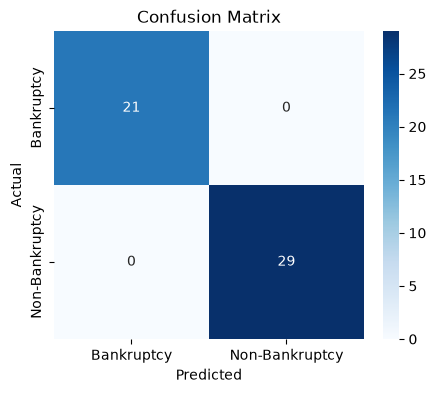


Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        21
           1       1.00      1.00      1.00        29

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50



In [87]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

as_cb = accuracy_score(y_test, y_pred_cb)
cm_cb = confusion_matrix(y_test, y_pred_cb)
cr_cb = classification_report(y_test, y_pred_cb)

# Accuracy
print("Accuracy Score:", as_cb)

# Confusion Matrix
plt.figure(figsize=(5,4))
sns.heatmap(cm_cb,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=['Bankruptcy', 'Non-Bankruptcy'],
            yticklabels=['Bankruptcy', 'Non-Bankruptcy']
           )

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nClassification Report:\n", cr_cb)

#### CatBoost ROC-AUC Evaluation

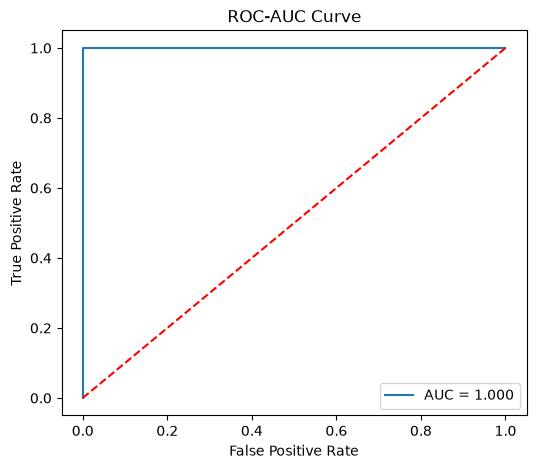

ROC-AUC Score: 1.0


In [88]:
from sklearn.metrics import roc_curve, roc_auc_score

# Probability of Positive Class
y_prob_cb = cb_model.predict_proba(X_test)[:,1]

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob_cb)

# AUC Score
auc_score = roc_auc_score(y_test, y_prob_cb)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0,1], [0,1], linestyle='--', color='red')

plt.title("ROC-AUC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

print("ROC-AUC Score:", auc_score)

#### Model Performance Comparison

In [93]:
from sklearn.metrics import classification_report

cr_lr_dict = classification_report(y_test, y_pred_lr, output_dict=True)
cr_knn_dict = classification_report(y_test, y_pred_knn, output_dict=True)
cr_svm_dict = classification_report(y_test, y_pred_svm, output_dict=True)
cr_dt_dict = classification_report(y_test, y_pred_dt, output_dict=True)
cr_rf_dict = classification_report(y_test, y_pred_rf, output_dict=True)
cr_gb_dict = classification_report(y_test, y_pred_gb,output_dict=True)
cr_xgb_dict = classification_report(y_test, y_pred_xgb, output_dict=True)
cr_lgbm_dict = classification_report(y_test, y_pred_lgbm, output_dict=True)
cr_cb_dict = classification_report(y_test, y_pred_cb, output_dict=True)

comparison_df = pd.DataFrame ({
    "Model": [
        'Logistic Regression',
        'KNN Classifier',
        'SVM Classifier',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting',
        'XGBoost Classifier',
        'LightGBM Classifier',
        'CatBoost Classifier'
    ],
    "Accuracy": [
        as_lr,
        as_knn,
        as_svm,
        as_dt,
        as_rf,
        as_gb,
        as_xgb,
        as_lgbm,
        as_cb
    ],
    "Precision": [
        cr_lr_dict["weighted avg"]["precision"],
        cr_knn_dict["weighted avg"]["precision"],
        cr_svm_dict["weighted avg"]["precision"],
        cr_dt_dict["weighted avg"]["precision"],
        cr_rf_dict["weighted avg"]["precision"],
        cr_gb_dict["weighted avg"]["precision"],
        cr_xgb_dict["weighted avg"]["precision"],
        cr_lgbm_dict["weighted avg"]["precision"],
        cr_cb_dict["weighted avg"]["precision"]
    ],
    "Recall": [
        cr_lr_dict["weighted avg"]["recall"],
        cr_knn_dict["weighted avg"]["recall"],
        cr_svm_dict["weighted avg"]["recall"],
        cr_dt_dict["weighted avg"]["recall"],
        cr_rf_dict["weighted avg"]["recall"],
        cr_gb_dict["weighted avg"]["recall"],
        cr_xgb_dict["weighted avg"]["recall"],
        cr_lgbm_dict["weighted avg"]["recall"],
        cr_cb_dict["weighted avg"]["recall"]
    ],
    "F1-Score": [
        cr_lr_dict["weighted avg"]["f1-score"],
        cr_knn_dict["weighted avg"]["f1-score"],
        cr_svm_dict["weighted avg"]["f1-score"],
        cr_dt_dict["weighted avg"]["f1-score"],
        cr_rf_dict["weighted avg"]["f1-score"],
        cr_gb_dict["weighted avg"]["f1-score"],
        cr_xgb_dict["weighted avg"]["f1-score"],
        cr_lgbm_dict["weighted avg"]["f1-score"],
        cr_cb_dict["weighted avg"]["f1-score"]
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_knn),
        roc_auc_score(y_test, y_prob_svm),
        roc_auc_score(y_test, y_prob_dt),
        roc_auc_score(y_test, y_prob_rf),
        roc_auc_score(y_test, y_prob_gb),
        roc_auc_score(y_test, y_prob_xgb),
        roc_auc_score(y_test, y_prob_lgbm),
        roc_auc_score(y_test, y_prob_cb)
    ]
})

comparison_df = comparison_df.sort_values(by='ROC-AUC', ascending=False).round(3)
comparison_df

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
1,KNN Classifier,0.98,0.981,0.98,0.98,1.000
7,LightGBM Classifier,0.98,0.981,0.98,0.98,1.000
2,SVM Classifier,1.00,1.000,1.00,1.00,1.000
4,Random Forest,1.00,1.000,1.00,1.00,1.000
5,Gradient Boosting,0.98,0.981,0.98,0.98,1.000
8,CatBoost Classifier,1.00,1.000,1.00,1.00,1.000
6,XGBoost Classifier,0.98,0.981,0.98,0.98,1.000
0,Logistic Regression,1.00,1.000,1.00,1.00,1.000
3,Decision Tree,0.98,0.981,0.98,0.98,0.983


#### Hyperparameter Tuning

###### Hyperparameter tuning was not performed because the selected Random Forest model already achieved perfect performance on the test dataset (Accuracy = 100%, Precision = 100%, Recall = 100%, F1-Score = 100%, ROC-AUC = 1.00). Since no further improvement in predictive performance was possible, the default model was selected as the final model.

#### Best Model Selection:
###### Among all the evaluated models, the Random Forest Classifier was selected as the final model because it achieved 100% Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score on the test dataset. Its strong predictive performance and robustness make it the most suitable model for bankruptcy prediction.

#### Train and Test Score

In [95]:
print("Train Score:", rf_model.score(X_train, y_train))
print("Test Score:", rf_model.score(X_test, y_test))

Train Score: 1.0
Test Score: 1.0


###### The Random Forest model achieved a training score of 1.00 and a testing score of 1.00, indicating consistent performance on both datasets. Based on the train-test split, there is no evidence of performance degradation on the test set.

#### Feature Importance Analysis

In [99]:
feature_importance = pd.DataFrame ({
    "Features": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(by='Importance', ascending=False).round(3)
feature_importance

,Features,Importance
4,competitiveness,0.471
3,credibility,0.258
2,financial_flexibility,0.198
1,management_risk,0.029
5,operating_risk,0.025
0,industrial_risk,0.020


#### Feature Importance Visualization

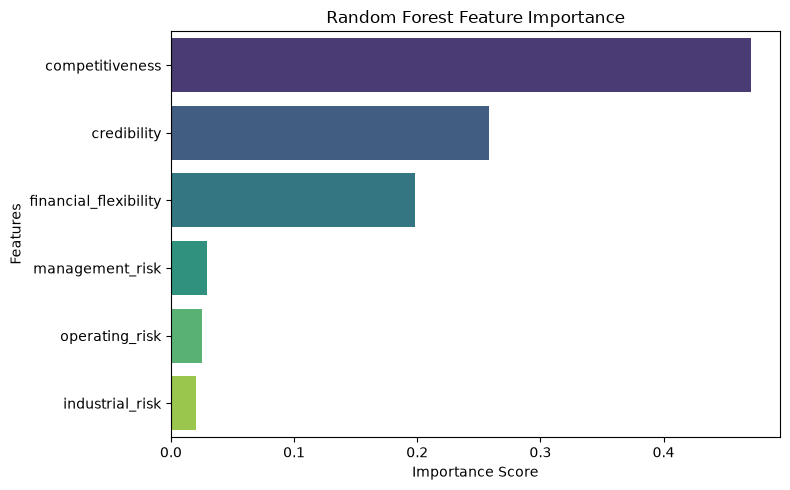

In [104]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Features",
    hue="Features",
    palette="viridis",
    legend=False
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.tight_layout()
plt.show()

#### Save the Final Model

In [105]:
import joblib

joblib.dump(rf_model, "rf_final_model.pkl")

['rf_final_model.pkl']

#### Save Feature Columns

In [108]:
joblib.dump(X.columns.tolist(), "feature_columns.pkl")

['feature_columns.pkl']